In [1]:
from Crypto.Util.number import  bytes_to_long, long_to_bytes
from sage.all import *



```python
from sage.all import *

a,b,p = ?,?,?

pt1="L3AK{test_"
pt2="flag}"

E = EllipticCurve(Zmod(p), [a, b])
p,q=E.random_element(),E.random_element()
u=bytes_to_long(pt1.encode())*p
v=bytes_to_long(pt2.encode())*q

# I will help u <3
print(p,u,q,v)


```

In [2]:
# p
x1,y1,_ = (103905521866731574234430443362297034336 , 116589269353056499566212456950780999584 , 1)
# q
x2,y2,_ = (161940138185633513360673631821653803879 , 167867902631659599239485617419980253311 , 1)
# u
xx1,yy1,_ = (171660318017081135625337806416866746485 , 122407097490400018041253306369079974706 , 1)
# v
xx2,yy2,_ = (95406403280474692216804281695624776780 , 109560844064302254814641159241201048462 , 1)
#           p       u           q       v
points = [(x1,y1),(xx1,yy1),(x2,y2),(xx2,yy2)]
points

[(103905521866731574234430443362297034336,
  116589269353056499566212456950780999584),
 (171660318017081135625337806416866746485,
  122407097490400018041253306369079974706),
 (161940138185633513360673631821653803879,
  167867902631659599239485617419980253311),
 (95406403280474692216804281695624776780,
  109560844064302254814641159241201048462)]

In [3]:
from itertools import combinations
combs = list(combinations(points,r=2))

$y^2 = x^3 + ax + b$

Points $(x_i,y_i)$ for $i$ in 1,2

=> $y_{0}^2 - y_{1}^2 = (x_{0}^3 - x_{1}^3) + a \cdot (x_{0} - x_{1})$

In [4]:
def compute_a(p1,p2,p=0):
    (x1,y1) = p1
    (x2,y2) = p2
    
    if p:
        inv = pow((x2 - x1),-1,p)
        return (((y2**2 - y1**2) - (x2**3 - x1**3))*(inv))%p 
    else:
        assert ((y2**2 - y1**2) - (x2**3 - x1**3)) % (x2 - x1) == 0
        return ((y2**2 - y1**2) - (x2**3 - x1**3))//(x2 - x1)

def compute_b(p1,a):
    (x1,y1) = p1
    return y1**2 - x1**3 - a * x1
    
def compute_p(p1,p2,a,b):
    (x1,y1) = p1
    (x2,y2) = p2
    return gcd(y1**2 - x1**3 - a*x1 - b,y2**2 - x2**3 - a*x2 - b)

def check(p1,a,b,p):
    (x1,y1) = p1
    return pow(y1,2,p) == (pow(x1,3,p) + a*x1 + b) % p


In [5]:
for p1,p2 in combs:
    try:
        a = compute_a(p1,p2)
        b = compute_b(p1,a)
        p = compute_p(p1,p2,a,b)
        
        if Integer(p).is_prime() and check(p1,a,b,p) and check(p2,a,b,p):
            print(a,b,p)
        else:
            print(Integer(p).factor())
    except AssertionError:
        print("Invalid inverse:",p1,p2)

Invalid inverse: (103905521866731574234430443362297034336, 116589269353056499566212456950780999584) (171660318017081135625337806416866746485, 122407097490400018041253306369079974706)
Invalid inverse: (103905521866731574234430443362297034336, 116589269353056499566212456950780999584) (161940138185633513360673631821653803879, 167867902631659599239485617419980253311)
Invalid inverse: (103905521866731574234430443362297034336, 116589269353056499566212456950780999584) (95406403280474692216804281695624776780, 109560844064302254814641159241201048462)
Invalid inverse: (171660318017081135625337806416866746485, 122407097490400018041253306369079974706) (161940138185633513360673631821653803879, 167867902631659599239485617419980253311)
Invalid inverse: (171660318017081135625337806416866746485, 122407097490400018041253306369079974706) (95406403280474692216804281695624776780, 109560844064302254814641159241201048462)
Invalid inverse: (161940138185633513360673631821653803879, 1678679026316595992394856174

$y^2 = x^3 + ax + b$

Points $(x_i,y_i)$ for $i$ in 1,2

=> $y_{0}^2 - x_{0}^3 -a \cdot x_{0} = b$

In [6]:
def calc(x,a,b):
    return x**3 + a*x + b

$y^2 = x^3 + ax + b \mod p$

However, we need to find $p$ first to actually get $a$ due to the need for a modular inverse.

$y^2 = x^3 + ax + b \mod p$ and $u^2 = v^3 + av + b \mod p$

$a-b \implies y^2-u^2 = x^3 + ax - v^3 + av \iff y^2-u^2 = (x^3 - v^3) + a \cdot (x-v) \mod p$

With the definition of $x \mod p = x - kp$, we can rewrite it

$(y^2-u^2) - (x^3 - v^3) = a \cdot (x-v) - kp$ 

$(j^2-k^2) - (j^3 - k^3) = a \cdot (j-k) - k'p$ 

Let's first try to compute the $\gcd$ over a

In [7]:
for p1,p2 in combs:
    (x1,y1) = p1
    (x2,y2) = p2
    print(gcd(((y2**2 - y1**2) - (x2**3 - x1**3)),(x2 - x1)))

1
1
4
1
1
27


Other idea, let's treat it as a linear problem with $y^2 - x^3 = c = ax + b \mod p$

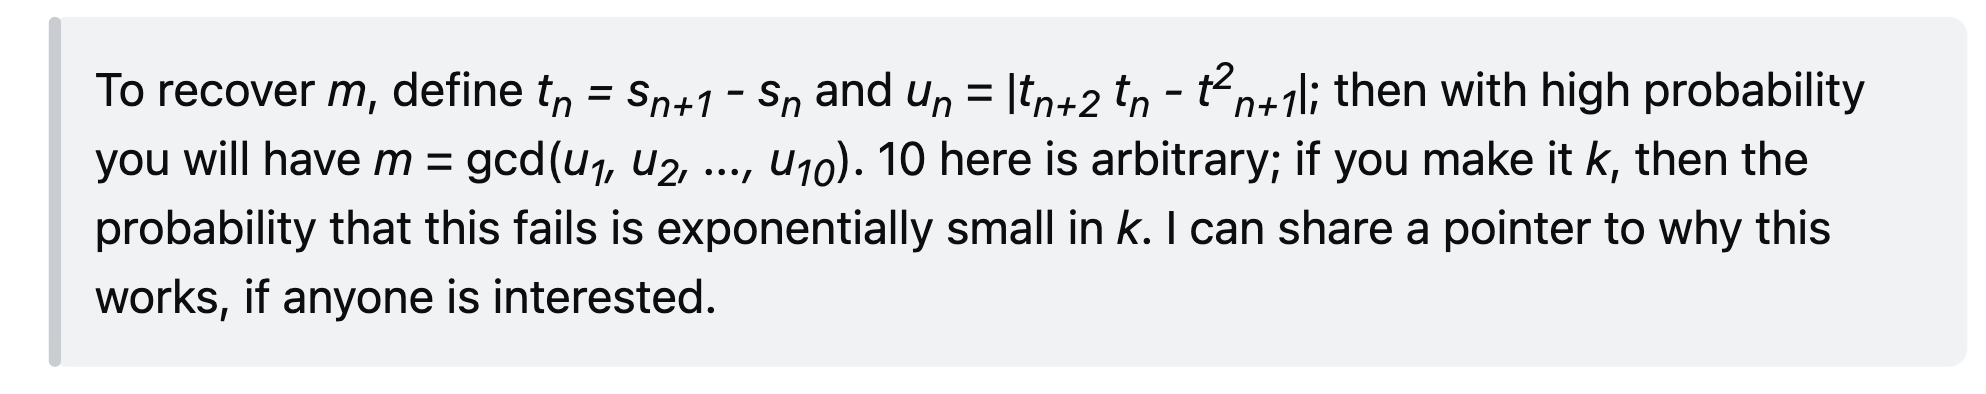

However, we only have 4 points, therefore 3 differences and not even in order :(

In [8]:
t = []
for i,point in enumerate(points):
    (x,y) = point
    print(y**2 - x**3, "=", f"a*{x} + b - k_{i} * p") 
    t.append(
        y**2 - x**3
    )
    
t = [b-a for a,b in zip(t,t[1:])]
t

-1121801157637094942914395227534058340935894942927814487306619042191515624385789420258525922225751983705744929152000 = a*103905521866731574234430443362297034336 + b - k_0 * p
-5058360043524522308260355467097673439278881882411555929141532187599021724127761032152184801198532763664886277847689 = a*171660318017081135625337806416866746485 + b - k_1 * p
-4246816700967080898629933938975832521428777260602752392490670915375463287688397603383367678567984575375431296857718 = a*161940138185633513360673631821653803879 + b - k_2 * p
-868425507575410336472903112447549349439052060615698172376185664836791049761816068606932602905705243937161397186556 = a*95406403280474692216804281695624776780 + b - k_3 * p


[-3936558885887427365345960239563615098342986939483741441834913145407506099741971611893658878972780779959141348695689,
 811543342557441409630421528121840917850104621808803536650861272223558436439363428768817122630548188289454980989971,
 3378391193391670562157030826528283171989725199987054220114485250538672237926581534776435075662279331438269899671162]

New Idea

$y^2 \equiv x^3 + ax + b \mod p\Rightarrow y^2 - x^3 \equiv ax + b \mod p$

$C_i \equiv a x_i + b \mod p \\
C_j \equiv a x_j + b \mod p$

$C_i - C_j \equiv a(x_i - x_j) \mod p$

Because we have 4 points, we can cancel $a$ out:

$\dfrac{C_i - C_j}{x_i - x_j} \equiv a \mod p$

$\dfrac{C_0 - C_1}{x_0 - x_1} \equiv \dfrac{C_2 - C_3}{x_2 - x_3} \iff (C_0 - C_1)\cdot(x_2 - x_3) \equiv (C_2 - C_3)\cdot(x_0 - x_1) \mod p$

Therefore

$d = (C_0 - C_1)\cdot(x_2 - x_3) - (C_2 - C_3)\cdot(x_0 - x_1) \equiv 0 \mod p$

So we can use the old trick and try $\gcd(d,d')$ and hope to recover p. This works because $0 - 0 = 0 \mod p$. $d'$ just uses different points, from the 4 point, we can generate 3 $d_i$ values => $\gcd{d_0,d_1,d_2}$

In [9]:
def C(p1):
    (x1,y1) = p1
    return y1**2 - x1**3    
    
def X(p1,p2):
    (x1,_) = p1
    (x2,_) = p2
    return x1 - x2 

In [10]:
# First K expression
c01 = C(points[0]) - C(points[1])
c23 = C(points[2]) - C(points[3])
x01 = X(points[0], points[1])
x23 = X(points[2], points[3])
K1 = c01 * x23 - c23 * x01

# Second K expression from different points
c02 = C(points[0]) - C(points[2])
c13 = C(points[1]) - C(points[3])
x02 = X(points[0], points[2])
x13 = X(points[1], points[3])
K2 = c02 * x13 - c13 * x02

# Third K expression from different points
c03 = C(points[0]) - C(points[3])
c12 = C(points[1]) - C(points[2])
x03 = X(points[0], points[3])
x12 = X(points[1], points[2])
K3 = c03 * x03 - c12 * x12

gcd(K1,K2),gcd(K2,K3),gcd(K1,K3)

(190306311675782392867397794563277638587, 1, 1)

In [11]:
p = gcd(K1,K2)
p

190306311675782392867397794563277638587

In [12]:
a = compute_a(points[0],points[1],p)
a

121547024516589838748345110141426750807

In [13]:
b = compute_b(points[0],a) % p
b

7914092104289289683791712783390872437

In [14]:
check(points[0],a,b,p),check(points[1],a,b,p),check(points[3],a,b,p),check(points[2],a,b,p)

(True, True, True, True)

In [15]:
E = EllipticCurve(Zmod(p), [a, b])

In [16]:
check = [
    E.is_on_curve(x,y) for (x,y) in points
]
check

[True, True, True, True]

In [17]:
P,U,Q,V = [
    E((x,y)) for (x,y) in points
]
P.order(),int(Q.order()).bit_length()

(190306311675782392867397794563277638587, 128)

In [18]:
P,U,Q,V

((103905521866731574234430443362297034336 : 116589269353056499566212456950780999584 : 1),
 (171660318017081135625337806416866746485 : 122407097490400018041253306369079974706 : 1),
 (161940138185633513360673631821653803879 : 167867902631659599239485617419980253311 : 1),
 (95406403280474692216804281695624776780 : 109560844064302254814641159241201048462 : 1))

In [ ]:
64*2**10

65536

In [ ]:
# lower=bytes_to_long(b"0" * len("L3AK{test_"))
# upper=bytes_to_long(b"{" * len("L3AK{test_"))

lower=bytes_to_long(b"!!!!}")
upper=bytes_to_long(b"}}}}}")
print(lower,upper, (upper - lower).bit_count())
discrete_log(V,Q,algorithm="bsgs",operation="+",bounds=(lower,upper))

142289740157 526040857213 16


ValueError: no discrete log of (1244179970258833502117609976357073457 : 55637678387586045893693757052146798195 : 1) found to base (161940138185633513360673631821653803879 : 167867902631659599239485617419980253311 : 1)

In [47]:
long_to_bytes(439904987005)

b'flag}'

In [36]:
bytes_to_long(b"L3AK{$<y1") > bytes_to_long(b"L3AK{!!!!")

True

In [37]:
bytes_to_long(b"L3AK{$<y1") < bytes_to_long(b"L3AK{~~~~")

True

In [55]:
lower=bytes_to_long("L3AK{!!!!!".encode())
upper=bytes_to_long("L3AK{~~~~~".encode())

# lower=bytes_to_long(b"0" * len("flag}"))
# upper=bytes_to_long(b"}" * len("flag}"))

print(lower,upper, (upper - lower).bit_count())
discrete_log(U,P,algorithm="bsgs",operation="+",bounds=(lower,upper))

359845341635470161944865 359845341635871160303230 25


ValueError: no discrete log of (131046261659169902283342116491618413716 : 123672445001602244959265133580811478494 : 1) found to base (103905521866731574234430443362297034336 : 116589269353056499566212456950780999584 : 1)

| Algorithm           | Time Complexity        | Memory Usage        | Bounds Supported | Best For                                          |
|---------------------|------------------------|----------------------|------------------|----------------------------------------------------|
| Rho (`"rho"`)       | O(√N)                  | O(1)                 | ❌ No            | Full-group DLP, memory-limited environments       |
| Kangaroo (`"lambda"`) | O(√(b − a))        | O(log(b − a))        | ✅ Yes           | Bounded DLP when `x ∈ [lower, upper]`  [oai_citation:0‡doc.sagemath.org](https://doc.sagemath.org/html/en/reference/groups/sage/groups/generic.html?utm_source=chatgpt.com) |
| Baby-Step Giant-Step (`"bs-gs"`) | O(√N)  | O(√N)                | ✅ Yes           | Deterministic DLP when enough memory is available |
| Generic (no algorithm specified) | Varies | Varies           | ❓ Varies        | Fallback; may not respect bounds                  |

In [27]:
import sys
type(P),sys.getsizeof(P),P.__dict__

(sage.schemes.elliptic_curves.ell_point.EllipticCurvePoint_finite_field,
 64,
 {'_codomain': Elliptic Curve defined by y^2 = x^3 + 121547024516589838748345110141426750807*x + 7914092104289289683791712783390872437 over Ring of integers modulo 190306311675782392867397794563277638587,
  '_normalized': True,
  '_coords': (103905521866731574234430443362297034336,
   116589269353056499566212456950780999584,
   1),
  '_order': 190306311675782392867397794563277638587,
  'codomain': The constant function (...) -> Elliptic Curve defined by y^2 = x^3 + 121547024516589838748345110141426750807*x + 7914092104289289683791712783390872437 over Ring of integers modulo 190306311675782392867397794563277638587})

In [ ]:
int(str(p)).bit_length(),long_to_bytes(p).__len__()

(128, 16)

In [39]:
pt1min=bytes_to_long(("L3AK{" + "!" * (16 - len("L3AK{"))).encode())
pt1max=bytes_to_long(("L3AK{" + "~" * (16 - len("L3AK{"))).encode())
pt2min=bytes_to_long(("!" * (16 - len("}")) + "}").encode())
pt2max=bytes_to_long(("~" * (16 - len("}")) + "}").encode())
ord("!"),ord("~")

(33, 126)

In [41]:
(pt1max-pt1min).bit_length(),(pt2max-pt2min).bit_length(),p.bit_length()

(87, 127, 128)

# New idea: Pairing

- We can see that the search space is huge, but `bsgs`/`Lambda` reduces it by 2. However, we hit memory limits with bsgs, as one point is $64$ bytes big.
- $p = P.order$

In [44]:
assert p == P.order()

Let's recap: 

- We have a weierstrass curve
- $p == P.order$
- $P.order == hl$ where $h$ is the cofactor and $l$ a large prime. The prime factors of the order depict the possible subgroups(!sub group attack). Low cofactors are safe!

According to [Safecuves](https://safecurves.cr.yp.to/transfer.html)

> A "transfer" converts ECDLP into a "linear algebraic group" DLP. There are several types of transfers for an elliptic-curve group of prime order ℓ over a prime field F_p:

- Additive transfer: applicable when ℓ equals p. The target group is the additive group F_p, where DLP is very easy to solve.
- Degree-1 multiplicative transfer: applicable when ℓ divides p-1. The target group is the multiplicative group F_p^*, where DLP is solved in subexponential time by index calculus. The standard estimates are that current index-calculus methods break DLP in F_p^* at cost below 2^128 for p up to roughly 2^3000.
- Degree-2 multiplicative transfer: applicable when ℓ divides p^2-1. The target group is the multiplicative group F_{p^2}^*, where DLP is solved in subexponential time by index calculus. The standard estimates are that current index-calculus methods break DLP in F_{p^2}^* at cost below 2^128 for p up to roughly 2^1500.
- Degree-3 multiplicative transfer: applicable when ℓ divides p^3-1. The target group is the multiplicative group F_{p^3}^*, where DLP is solved in subexponential time by index calculus. The standard estimates are that current index-calculus methods break DLP in F_{p^3}^* at cost below 2^128 for p up to roughly 2^1000.
Et cetera.


Just reading this, we can execute an additive transfer as $F_p$ equals $l$. I guess you do this via weil paring

In [52]:
base_point = P * P.order()

(0 : 1 : 0)

In [63]:
assert P.order() == E.base_field().order()
wP = P.weil_pairing(Q,n=P.order())
wP

1

In [61]:
tP = P.tate_pairing(Q,n=P.order(),k=1)
tP

TypeError: no conversion of this rational to integer

In [70]:
E,P.order()

(Elliptic Curve defined by y^2 = x^3 + 121547024516589838748345110141426750807*x + 7914092104289289683791712783390872437 over Ring of integers modulo 190306311675782392867397794563277638587,
 190306311675782392867397794563277638587)

In [91]:
# P,U,Q,V, U=Px V=Qy
assert E.order() == P.order() == Q.order()
U.weil_pairing(V,n=p)

1

In [ ]:
assert E.gen(0).order() == P.order()
P.weil_pairing(E.gen(0),n=E.order())

1

# Okay, my idea does not work, as we always have `e(P,Pn) = e(P,P)^n = 1^n`

There is literally a [paper](https://link.springer.com/article/10.1007/s001459900052) describing the solution from 1999 by Nigel Smart. The technique is to lift points into $Q$: 

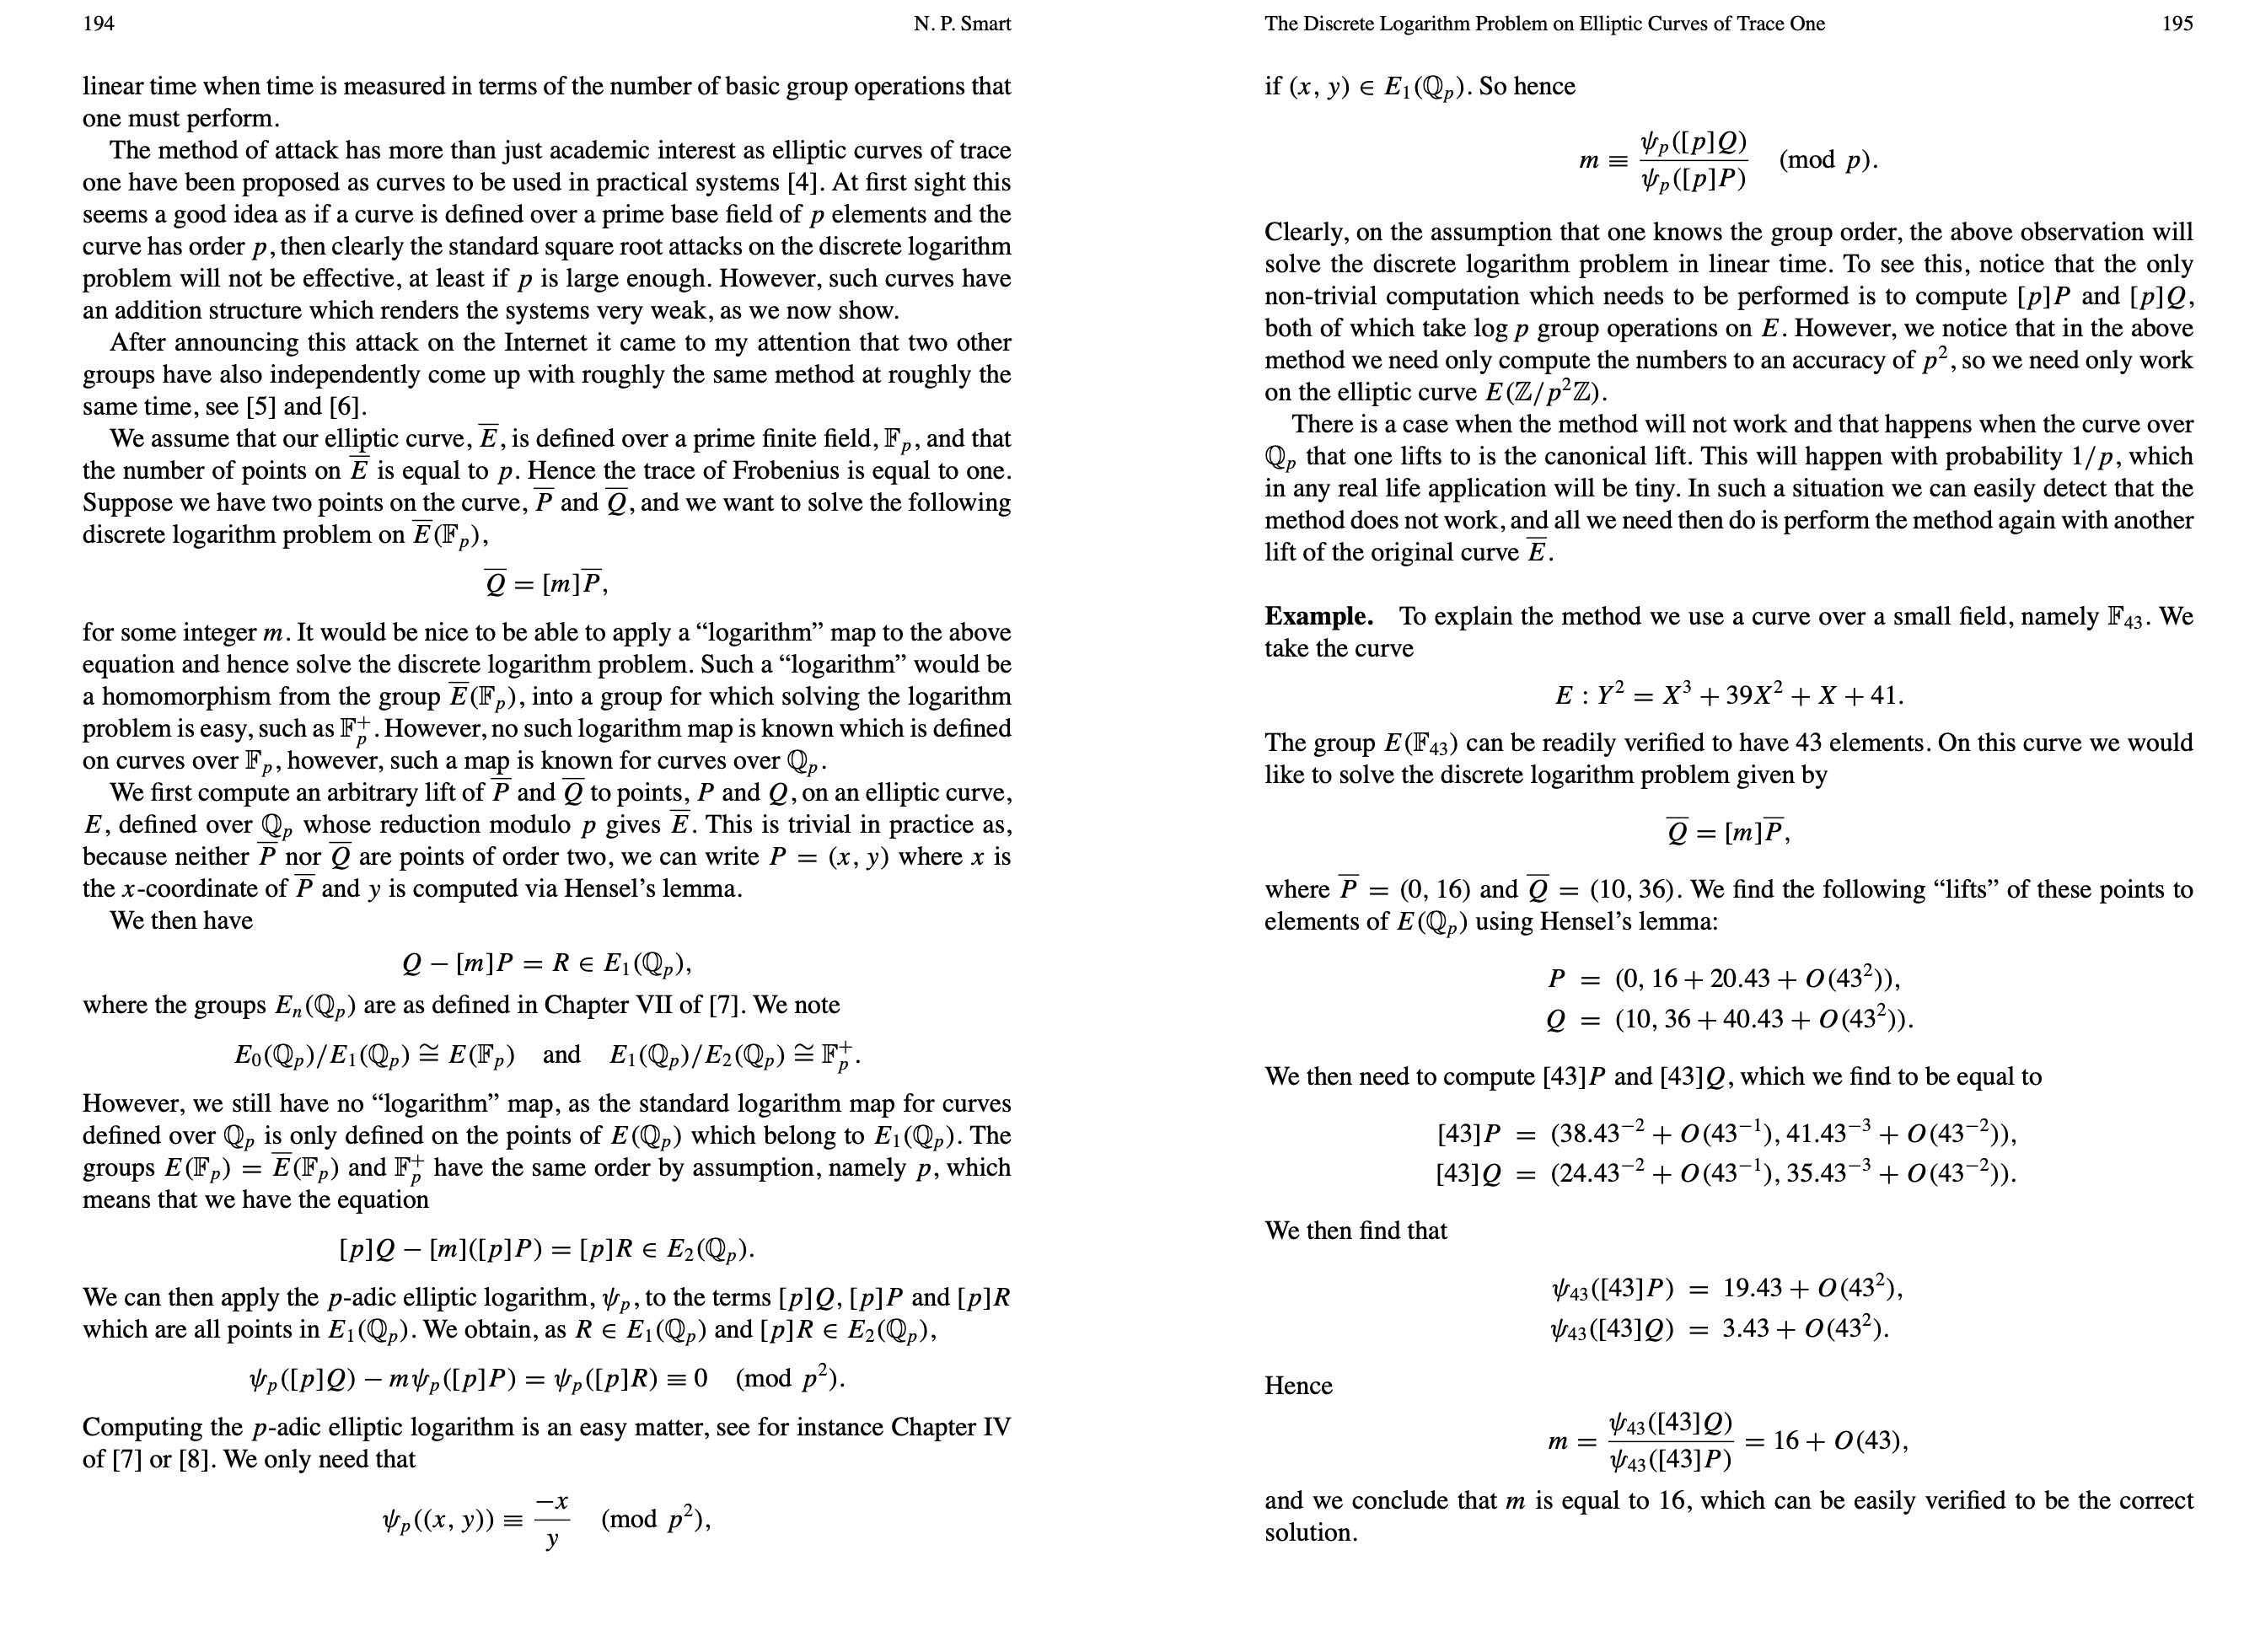

In [23]:
a,b,p

(121547024516589838748345110141426750807,
 7914092104289289683791712783390872437,
 190306311675782392867397794563277638587)

In [19]:
E = EllipticCurve(GF(p), [a,b])
assert E.order() == p

QFieldp = Qp(p, 2)
Ep = EllipticCurve(QFieldp, [0, 0, 0, a,b])

A = a
B = b 

In [23]:
xP,yP = points[0]
xQ,yQ = points[1]

yPp = sqrt(QFieldp(xP) ** 3 + QFieldp(A) * QFieldp(xP) + QFieldp(B))
Pp = Ep(QFieldp(xP), (-yPp, yPp)[yPp[0] == yP])

yQp = sqrt(QFieldp(xQ) ** 3 + QFieldp(A) * QFieldp(xQ) + QFieldp(B))
Qp = Ep(QFieldp(xQ), (-yQp, yQp)[yQp[0] == yQ])

print('Pp = {}'.format(Pp))
print('Qp = {}'.format(Qp))
print('-' * 40)

lQ = Ep.formal_group().log()(- (p * Qp)[0] // (p * Qp)[1]) / p
print('log(Q) = {}'.format(lQ))
lP = Ep.formal_group().log()(- (p * Pp)[0] // (p * Pp)[1]) / p
print('log(P) = {}'.format(lP))
print('-' * 40)

e = lQ / lP
print('e = {}'.format(e))

Pp = (103905521866731574234430443362297034336 + O(190306311675782392867397794563277638587^2) : 116589269353056499566212456950780999584 + 36963121577948037177631457556850479030*190306311675782392867397794563277638587 + O(190306311675782392867397794563277638587^2) : 1 + O(190306311675782392867397794563277638587^2))
Qp = (171660318017081135625337806416866746485 + O(190306311675782392867397794563277638587^2) : 122407097490400018041253306369079974706 + 29953288005423716474668829501562423588*190306311675782392867397794563277638587 + O(190306311675782392867397794563277638587^2) : 1 + O(190306311675782392867397794563277638587^2))
----------------------------------------
log(Q) = 33400491853336087272839919232405465955 + O(190306311675782392867397794563277638587)
log(P) = 4231564869616568597460640806831632509 + O(190306311675782392867397794563277638587)
----------------------------------------
e = 395654137329322474453269072294538847 + O(190306311675782392867397794563277638587)


/tmp/ipykernel_5166/2083702798.py:5: DeprecationWarning: __getitem__ is changing to match the behavior of number fields. Please use expansion instead.
See https://github.com/sagemath/sage/issues/14825 for details.
  Pp = Ep(QFieldp(xP), (-yPp, yPp)[yPp[0] == yP])
/tmp/ipykernel_5166/2083702798.py:8: DeprecationWarning: __getitem__ is changing to match the behavior of number fields. Please use expansion instead.
See https://github.com/sagemath/sage/issues/14825 for details.
  Qp = Ep(QFieldp(xQ), (-yQp, yQp)[yQp[0] == yQ])


In [24]:
long_to_bytes(395654137329322474453269072294538847)

b'L3AK{5m4rt1_1n_'

In [28]:
# taken form https://hxp.io/blog/25/SharifCTF-2016-crypto350-British-Elevator-writeup/ --- CARE: HORRIBLE CODE BELOW
xP,yP = points[2]
xQ,yQ = points[3]

yPp = sqrt(QFieldp(xP) ** 3 + QFieldp(A) * QFieldp(xP) + QFieldp(B))
Pp = Ep(QFieldp(xP), (-yPp, yPp)[yPp[0] == yP])

yQp = sqrt(QFieldp(xQ) ** 3 + QFieldp(A) * QFieldp(xQ) + QFieldp(B))
Qp = Ep(QFieldp(xQ), (-yQp, yQp)[yQp[0] == yQ])

print('Pp = {}'.format(Pp))
print('Qp = {}'.format(Qp))
print('-' * 40)

lQ = Ep.formal_group().log()(- (p * Qp)[0] // (p * Qp)[1]) / p
print('log(Q) = {}'.format(lQ))
lP = Ep.formal_group().log()(- (p * Pp)[0] // (p * Pp)[1]) / p
print('log(P) = {}'.format(lP))
print('-' * 40)

e = lQ / lP
print('e = {}'.format(e))

Pp = (161940138185633513360673631821653803879 + O(190306311675782392867397794563277638587^2) : 167867902631659599239485617419980253311 + 127558235800639623397487224439265090429*190306311675782392867397794563277638587 + O(190306311675782392867397794563277638587^2) : 1 + O(190306311675782392867397794563277638587^2))
Qp = (95406403280474692216804281695624776780 + O(190306311675782392867397794563277638587^2) : 109560844064302254814641159241201048462 + 21695980340414212624032136331890882245*190306311675782392867397794563277638587 + O(190306311675782392867397794563277638587^2) : 1 + O(190306311675782392867397794563277638587^2))
----------------------------------------
log(Q) = 33743112877193866987329674616194458104 + O(190306311675782392867397794563277638587)
log(P) = 177055302598151179257158710541836080107 + O(190306311675782392867397794563277638587)
----------------------------------------
e = 438266376879025302776794239895413117 + O(190306311675782392867397794563277638587)


/tmp/ipykernel_5166/3012706351.py:6: DeprecationWarning: __getitem__ is changing to match the behavior of number fields. Please use expansion instead.
See https://github.com/sagemath/sage/issues/14825 for details.
  Pp = Ep(QFieldp(xP), (-yPp, yPp)[yPp[0] == yP])
/tmp/ipykernel_5166/3012706351.py:9: DeprecationWarning: __getitem__ is changing to match the behavior of number fields. Please use expansion instead.
See https://github.com/sagemath/sage/issues/14825 for details.
  Qp = Ep(QFieldp(xQ), (-yQp, yQp)[yQp[0] == yQ])


In [29]:
long_to_bytes(438266376879025302776794239895413117)

b'Th3_h00000d!!!}'

In [30]:
flag = long_to_bytes(395654137329322474453269072294538847) + long_to_bytes(438266376879025302776794239895413117)
flag.decode()

'L3AK{5m4rt1_1n_Th3_h00000d!!!}'